# eBay Tech Deals – Exploratory Data Analysis

In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\yasmi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_ebay_deals.csv')
print(df.shape)
df.head()

(209, 7)


,timestamp,title,price,original_price,shipping,item_url,discount_percentage
0,2026-03-12 09:05:26,"2021 Apple M1 Pro MacBook Pro 16"" 32GB/512GB S...",795.15,2699.00,Shipping info unavailable,https://www.ebay.com/itm/146647402645?_trkparm...,70.54
1,2026-03-12 09:05:27,"Bose Solo Soundbar 2 Home Theater, Certified R...",93.00,199.00,Shipping info unavailable,https://www.ebay.com/itm/167031735841?_trkparm...,53.27
2,2026-03-12 09:05:27,eufy SoloCam S3 Solar Wireless Security Camera...,89.99,199.99,Shipping info unavailable,https://www.ebay.com/itm/386708545260?_trkparm...,55.00
3,2026-03-12 09:05:27,VIZIO 32” Class Full HD 1080p LED Smart TV VFD...,89.99,169.99,Shipping info unavailable,https://www.ebay.com/itm/235812307908?_trkparm...,47.06
4,2026-03-12 09:05:27,Apple Pencil (USB-C) - White Stylus MUWA3AM/A ...,51.82,56.95,Shipping info unavailable,https://www.ebay.com/itm/296262723993?_trkparm...,9.01


## 1. Time Series Analysis

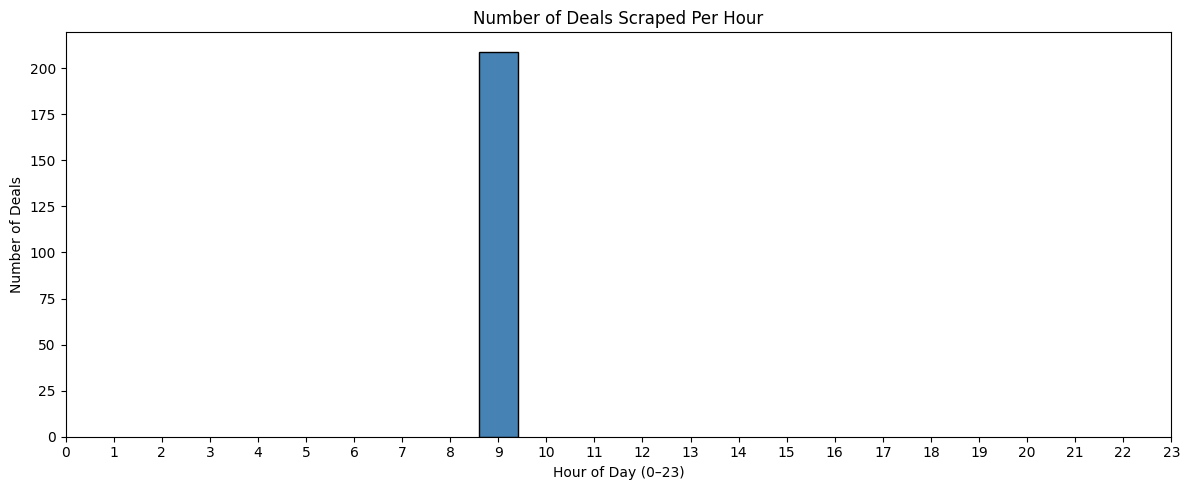

In [3]:
# Convert timestamp and sort
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Extract hour and count deals per hour
df['hour'] = df['timestamp'].dt.hour
deals_per_hour = df.groupby('hour').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
plt.bar(deals_per_hour['hour'], deals_per_hour['count'], color='steelblue', edgecolor='black')
plt.title('Number of Deals Scraped Per Hour')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Deals')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 2. Price and Discount Analysis

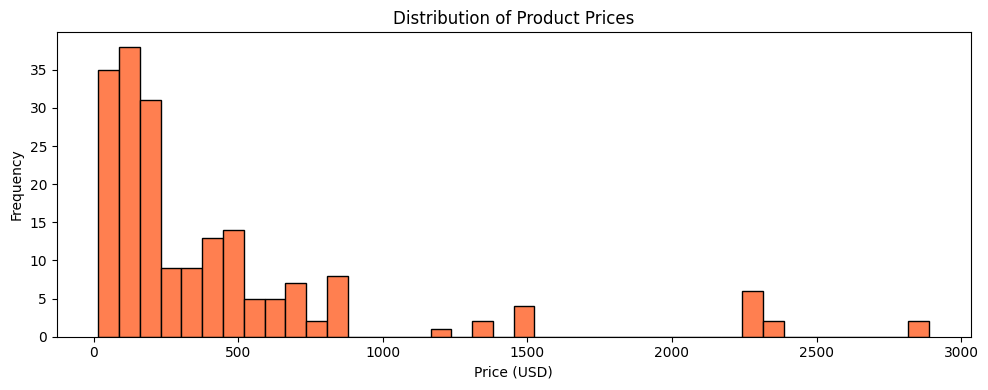

In [4]:
# Histogram of prices
plt.figure(figsize=(10, 4))
plt.hist(df['price'].dropna(), bins=40, color='coral', edgecolor='black')
plt.title('Distribution of Product Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

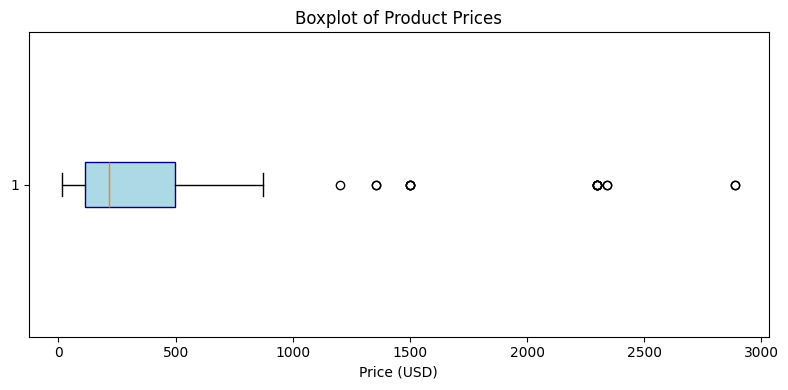

In [5]:
# Boxplot of prices
plt.figure(figsize=(8, 4))
plt.boxplot(df['price'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'))
plt.title('Boxplot of Product Prices')
plt.xlabel('Price (USD)')
plt.tight_layout()
plt.show()

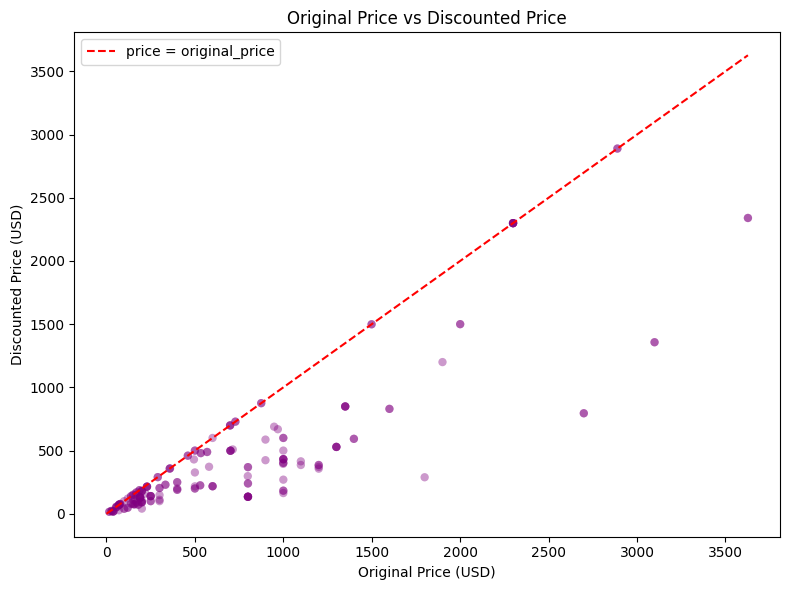

In [6]:
# Scatter plot: original_price vs price
plt.figure(figsize=(8, 6))
plt.scatter(df['original_price'], df['price'], alpha=0.4, color='purple', edgecolors='none')
max_val = max(df['original_price'].max(), df['price'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='price = original_price')
plt.title('Original Price vs Discounted Price')
plt.xlabel('Original Price (USD)')
plt.ylabel('Discounted Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

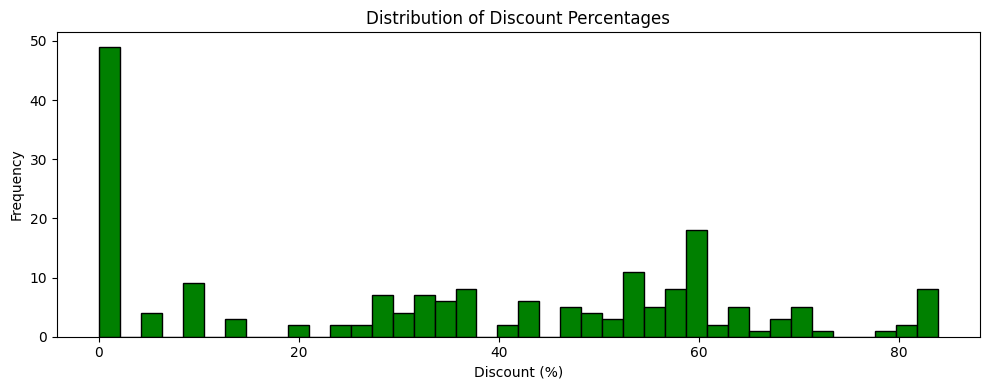

In [7]:
# Distribution of discount_percentage
plt.figure(figsize=(10, 4))
plt.hist(df['discount_percentage'].dropna(), bins=40, color='green', edgecolor='black')
plt.title('Distribution of Discount Percentages')
plt.xlabel('Discount (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Shipping Information Analysis

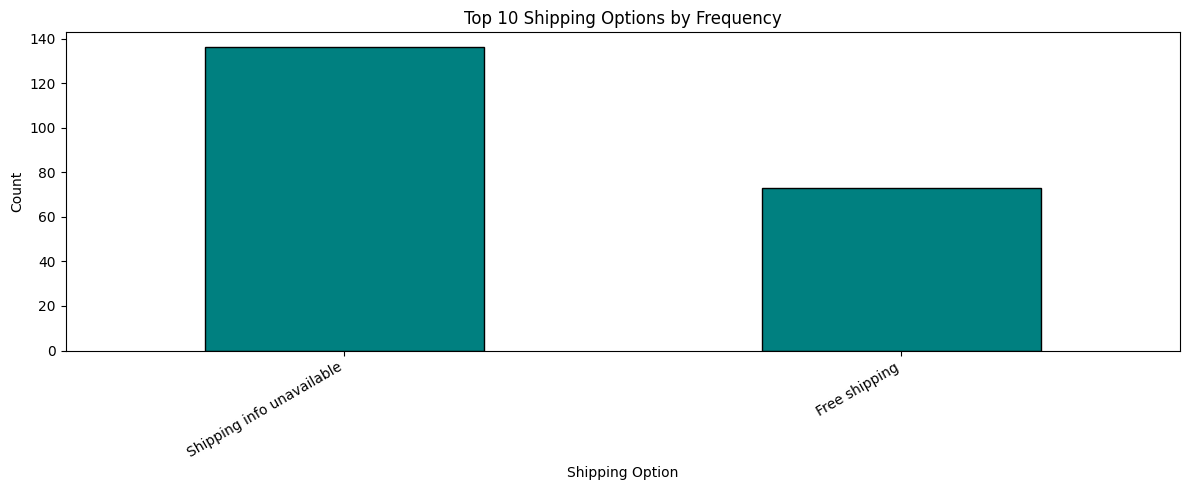

In [8]:
shipping_counts = df['shipping'].value_counts().head(10)

plt.figure(figsize=(12, 5))
shipping_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Shipping Options by Frequency')
plt.xlabel('Shipping Option')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Text Analysis on Product Titles

Apple      44
Samsung    32
iPhone     22
Tablet      7
Laptop      5
Gimbal      0
dtype: int64


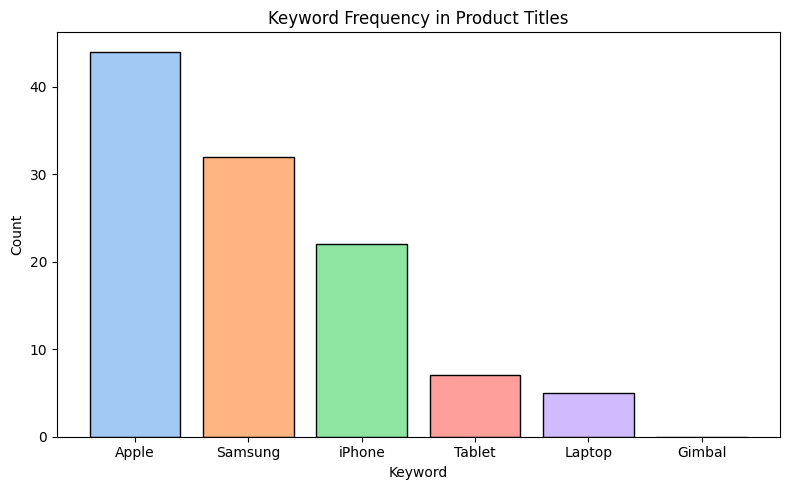

In [9]:
keywords = ['Apple', 'Samsung', 'Laptop', 'iPhone', 'Tablet', 'Gimbal']

keyword_counts = {
    kw: df['title'].dropna().str.contains(kw, case=False, regex=False).sum()
    for kw in keywords
}

kw_series = pd.Series(keyword_counts).sort_values(ascending=False)
print(kw_series)

plt.figure(figsize=(8, 5))
colors = sns.color_palette('pastel', len(kw_series))
plt.bar(kw_series.index, kw_series.values, color=colors, edgecolor='black')
plt.title('Keyword Frequency in Product Titles')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Price Difference Analysis

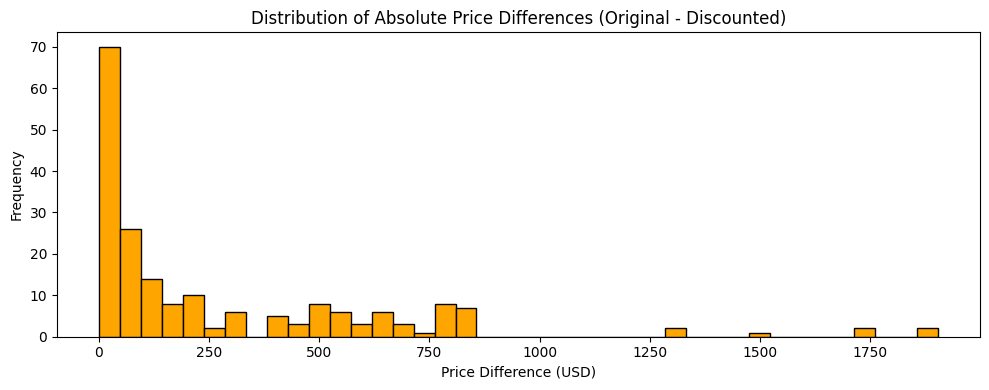

In [10]:
df['absolute_discount'] = df['original_price'] - df['price']

plt.figure(figsize=(10, 4))
plt.hist(df['absolute_discount'].dropna(), bins=40, color='orange', edgecolor='black')
plt.title('Distribution of Absolute Price Differences (Original - Discounted)')
plt.xlabel('Price Difference (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Top 5 Deals by Discount Percentage

In [11]:
top5 = (
    df[['title', 'price', 'original_price', 'discount_percentage']]
    .dropna(subset=['discount_percentage'])
    .sort_values('discount_percentage', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top5.index += 1  # start ranking from 1
print(top5.to_string())
top5

                                                                       title   price  original_price  discount_percentage
1  Google Pixel Fold 5G 256GB 7.6" T-Mobile Only, Obsidian Black - Excellent  288.99         1799.00                83.94
2                            Samsung Galaxy S22+ 128GB S906U Unlocked - Good  163.99          999.99                83.60
3                          Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99          799.99                83.13
4                          Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99          799.99                83.13
5                          Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99          799.99                83.13


,title,price,original_price,discount_percentage
1,"Google Pixel Fold 5G 256GB 7.6"" T-Mobile Only,...",288.99,1799.00,83.94
2,Samsung Galaxy S22+ 128GB S906U Unlocked - Good,163.99,999.99,83.60
3,Samsung Galaxy S21 5G 128GB G991U Unlocked - Good,134.99,799.99,83.13
4,Samsung Galaxy S21 5G 128GB G991U Unlocked - Good,134.99,799.99,83.13
5,Samsung Galaxy S21 5G 128GB G991U Unlocked - Good,134.99,799.99,83.13
